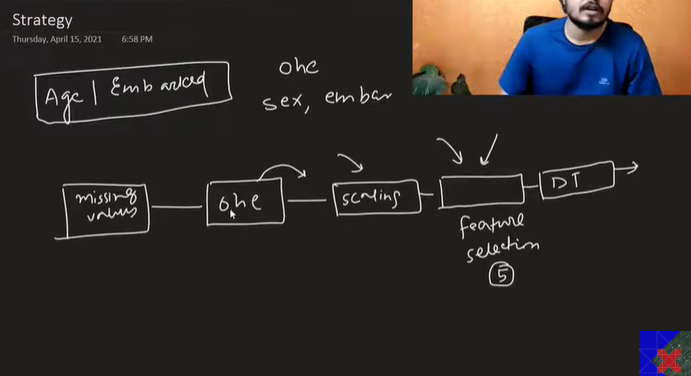

# process:
1. fill missing values in age,embarked using missing imputer using column transformer(array)
2. on that CT, perform ohe on age,embarked.(array)
3. scaling is done to get column in same numerical range
4. feature selection(choose best 5 cols)
5. decision tree class to train a model

In [16]:
import pandas as pd
import numpy as np

In [28]:
df=pd.read_csv('train.csv').drop(columns=['PassengerId','Name','Ticket','Cabin'])


In [29]:
# Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df[['Survived']],test_size=0.2,random_state=42)

In [30]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S
270,1,male,NaN,0,0,31.0000,S
860,3,male,41.0,2,0,14.1083,S
435,1,female,14.0,1,2,120.0000,S


## Step 1- simple imputing

In [15]:
from sklearn.compose import ColumnTransformer

In [25]:
# fill missing values in age and embarked
# while calling the column name, instead call by column index value as works on np array

trf1=ColumnTransformer(transformers=[
    ('impute_age',SimpleImputer(),[2]),
    ('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])],
    remainder='passthrough')
#total 7 columns

In [36]:
#ohe on embarked and sex
trf2=ColumnTransformer(transformers=[
    ('ohe_sex_embarked',OneHotEncoder(sparse_output=False),[1,6])
],remainder='passthrough')
# sex gets converted to 2 cols, embarked to 3
# total 10 cols

In [40]:
# scaling(normalization)
from sklearn.preprocessing import MinMaxScaler
trf3=ColumnTransformer(transformers=[
    ('scaling',MinMaxScaler(),slice(0,10))
],remainder='passthrough')


In [41]:
# feature scaling
from sklearn.feature_selection import SelectKBest,chi2
trf4 = SelectKBest(score_func=chi2,k=8)
# we are using the top 8 cols out of 10

In [44]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
trf5=DecisionTreeClassifier()

# Create pipeline

In [55]:
from sklearn.pipeline import Pipeline,make_pipeline

In [64]:
pipe =Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

In [65]:
pipe.fit(x_train,y_train)

ValueError: could not convert string to float: 'male'